# Final Model Comparison and Selection
Each model was developed and tuned in its own notebook:

| Model | Notebook |
|---|---|
| Logistic Regression | `Model_1_Logistic_Regression.ipynb` |
| Decision Tree | `Model_2_Decision_Tree.ipynb` |
| Random Forest | `Model_3_Random_Forest.ipynb` |
| KNN | `Model_4_KNN.ipynb` |

**Run the four model notebooks first.** This notebook then:
1. Loads the results of the four models
2. Compares them with a Dummy baseline
3. Compares baseline vs tuned models
4. Runs a feature selection experiment
5. Selects the final model and tests it once on the unseen test set
6. Justifies the final model
7. Saves the final model

## 1. Load the Results of the Four Models

In [1]:
import os
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# One results file per model, saved by each model notebook
files = ["logistic_regression", "decision_tree", "random_forest", "knn"]
results = pd.concat([pd.read_csv(f"results/{f}_results.csv") for f in files]).set_index("Model")

results[["Baseline Accuracy", "Baseline F1 (macro)", "Baseline Train F1",
         "Baseline High Risk Recall", "Tuned F1", "Best Params"]].round(4)

,Baseline Accuracy,Baseline F1 (macro),Baseline Train F1,Baseline High Risk Recall,Tuned F1,Best Params
Model,,,,,,
Logistic Regression,0.4992,0.4663,0.4668,0.2887,0.4663,"{""C"": 10, ""class_weight"": null}"
Decision Tree,0.5624,0.5511,0.9988,0.5032,0.5860,"{""max_depth"": 25, ""min_samples_leaf"": 20}"
Random Forest,0.6158,0.6025,0.9987,0.5223,0.6121,"{""max_depth"": 25, ""n_estimators"": 200}"
KNN,0.5965,0.5802,0.7077,0.4698,0.5947,"{""n_neighbors"": 25, ""weights"": ""distance""}"


## 2. Dummy Baseline
A Dummy model always predicts the most common class (Low Risk). Every real model must score higher,
otherwise it has not learned anything useful.

In [2]:
train = pd.read_csv("data/train_processed.csv")
test = pd.read_csv("data/test_processed.csv")

X_train = train.drop(columns=["delay_risk_category"])
y_train = train["delay_risk_category"]
X_test = test.drop(columns=["delay_risk_category"])
y_test = test["delay_risk_category"]

# Same folds as the four model notebooks
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dummy_f1 = cross_val_score(DummyClassifier(strategy="most_frequent"), X_train, y_train,
                           cv=cv, scoring="f1_macro").mean()
print(f"Dummy Macro F1: {dummy_f1:.4f}")

Dummy Macro F1: 0.1943


## 3. Model Comparison: Baseline vs Tuned

In [3]:
compare = results[["Baseline F1 (macro)", "Tuned F1"]].copy()
compare.columns = ["Baseline F1", "Tuned F1"]
compare["Improvement"] = compare["Tuned F1"] - compare["Baseline F1"]
compare = compare.sort_values("Tuned F1", ascending=False)
compare.round(4)

,Baseline F1,Tuned F1,Improvement
Model,,,
Random Forest,0.6025,0.6121,0.0096
KNN,0.5802,0.5947,0.0146
Decision Tree,0.5511,0.5860,0.0350
Logistic Regression,0.4663,0.4663,0.0001


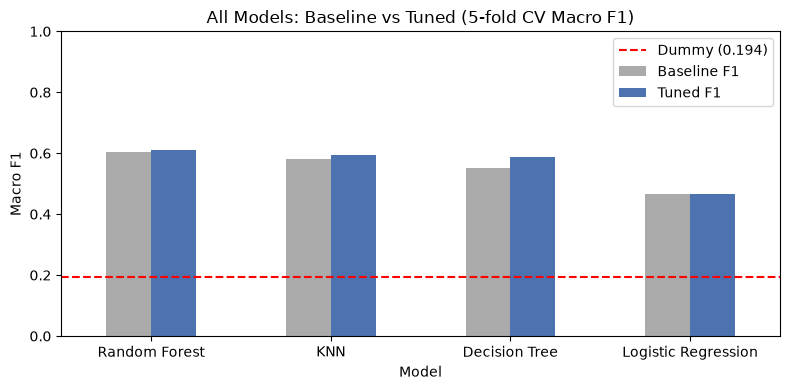

In [4]:
ax = compare[["Baseline F1", "Tuned F1"]].plot(kind="bar", figsize=(8, 4), color=["#AAAAAA", "#4C72B0"], rot=0)
ax.axhline(dummy_f1, color="red", linestyle="--", label=f"Dummy ({dummy_f1:.3f})")
ax.legend()
plt.title("All Models: Baseline vs Tuned (5-fold CV Macro F1)")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

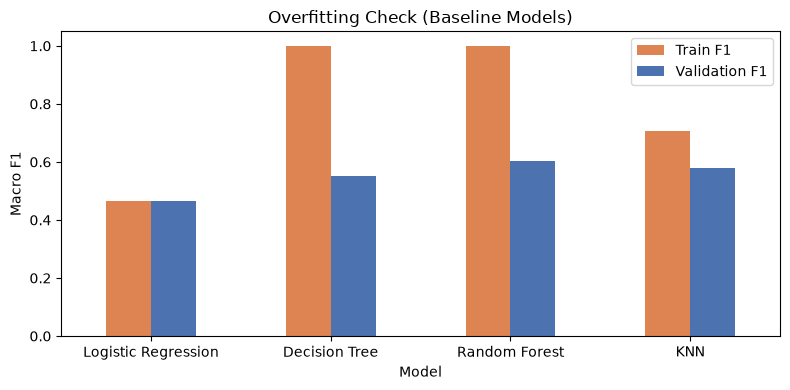

In [5]:
# Overfitting check for the baseline models: a big gap means the model memorises the training data
gap = results[["Baseline Train F1", "Baseline F1 (macro)"]]
gap.columns = ["Train F1", "Validation F1"]

gap.plot(kind="bar", figsize=(8, 4), color=["#DD8452", "#4C72B0"], rot=0)
plt.title("Overfitting Check (Baseline Models)")
plt.ylabel("Macro F1")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

**Observations:**
- All four models beat the Dummy baseline (0.19), so they learn real patterns.
- **Random Forest is the best** before and after tuning. **KNN** is second, **Decision Tree** third and **Logistic Regression** last.
- Decision Tree gained the most from tuning (+0.035) because limiting its depth fixed its overfitting.
- Logistic Regression did not improve: it is a linear model and the problem is non-linear (underfitting).
- Tree-based models have a high training score, but Random Forest still has the best validation score because it averages many trees.

## 4. Rebuild the Best Model
The best model is rebuilt with the best settings found by GridSearchCV in its model notebook.

In [6]:
# Default version of each model; the best settings are added on top
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(),
}

best_name = compare["Tuned F1"].idxmax()
best_params = json.loads(results.loc[best_name, "Best Params"])
best_model = base_models[best_name].set_params(**best_params)

print("Best model:", best_name)
print("Settings:", best_params)

Best model: Random Forest
Settings: {'max_depth': 25, 'n_estimators': 200}


## 5. Feature Selection Experiment
**Question:** Does removing weak features improve the model?
1. Train the tuned Random Forest and look at how important each feature is.
2. Remove the features with very low importance (below 0.01).
3. Re-run 5-fold CV for the best model with the smaller feature set and compare.

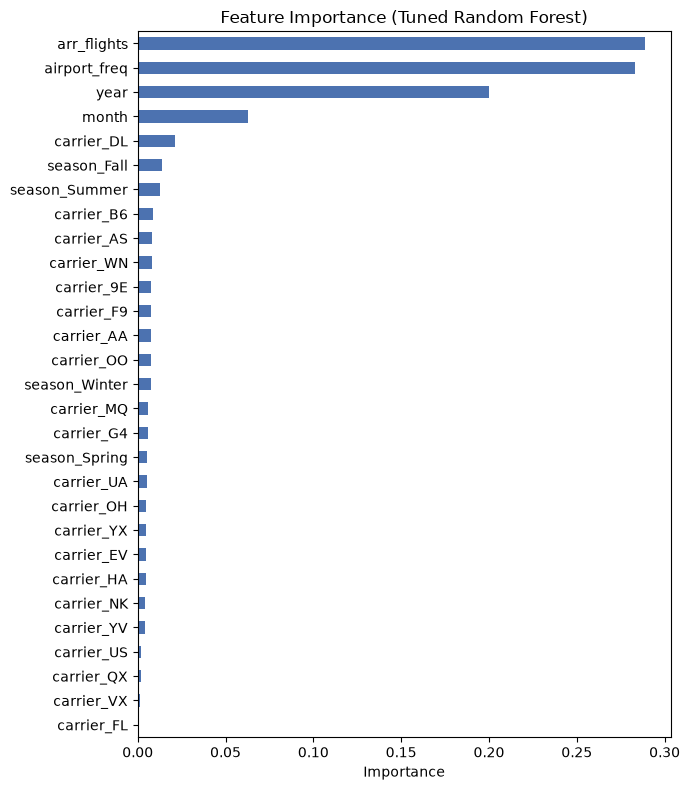

In [7]:
# Feature importance from the tuned Random Forest
rf_params = json.loads(results.loc["Random Forest", "Best Params"])
rf = base_models["Random Forest"].set_params(**rf_params)
rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()

importance.plot(kind="barh", figsize=(7, 8), color="#4C72B0")
plt.title("Feature Importance (Tuned Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [8]:
# Features with importance below 0.01 are treated as weak
weak_features = importance[importance < 0.01].index.tolist()
kept_features = [c for c in X_train.columns if c not in weak_features]

print("Weak features removed:", len(weak_features))
print(weak_features)
print("Features kept:", kept_features)

Weak features removed: 22
['carrier_FL', 'carrier_VX', 'carrier_QX', 'carrier_US', 'carrier_YV', 'carrier_NK', 'carrier_HA', 'carrier_EV', 'carrier_YX', 'carrier_OH', 'carrier_UA', 'season_Spring', 'carrier_G4', 'carrier_MQ', 'season_Winter', 'carrier_OO', 'carrier_AA', 'carrier_F9', 'carrier_9E', 'carrier_WN', 'carrier_AS', 'carrier_B6']
Features kept: ['year', 'month', 'arr_flights', 'season_Fall', 'season_Summer', 'carrier_DL', 'airport_freq']


In [9]:
from sklearn.base import clone

# 5-fold CV of the best model with only the kept features
# clone() gives a fresh UNFITTED copy (a fitted forest is huge to copy);
# the folds run one by one, and the trees inside each fold use all cores
rf_cv = clone(best_model).set_params(n_jobs=-1)

f1_all = compare.loc[best_name, "Tuned F1"]
f1_selected = cross_val_score(rf_cv, X_train[kept_features], y_train,
                              cv=cv, scoring="f1_macro", n_jobs=1).mean()

print(f"All {X_train.shape[1]} features : F1 = {f1_all:.4f}")
print(f"{len(kept_features)} selected features  : F1 = {f1_selected:.4f}")

All 29 features : F1 = 0.6121
7 selected features  : F1 = 0.5140


**Result of the feature selection experiment:**

| Feature set | Number of features | 5-fold CV Macro F1 |
|---|---|---|
| All features | 29 | **0.612** |
| Only features with importance ≥ 0.01 | 7 | 0.514 |

**Removing the weak features made the model worse** (F1 dropped by about 0.10), so **all 29 features are kept**.

**Why:** 20 of the 22 removed features are one-hot `carrier_` columns. One carrier column alone has low importance,
because each column only covers one airline. But *together* they tell the model which airline flies the route,
and the airline is an important factor for delays. Removing them removed the carrier information completely.

**Lesson:** feature importance should be judged for the whole original column (carrier), not for each one-hot column separately.

## 6. Final Model: Test-Set Evaluation
The final model is trained on all training data and evaluated **once** on the locked test set,
which none of the models has seen before.

In [10]:
# Use the feature set that scored better in the experiment above
final_features = kept_features if f1_selected > f1_all else list(X_train.columns)

final_model = best_model
final_model.fit(X_train[final_features], y_train)

y_pred = final_model.predict(X_test[final_features])

print("Final model:", best_name)
print("Number of features:", len(final_features))
print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Macro F1 : {f1_score(y_test, y_pred, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Low Risk", "Moderate Risk", "High Risk"]))

Final model: Random Forest
Number of features: 29
Test Accuracy : 0.6286
Test Macro F1 : 0.6153

               precision    recall  f1-score   support

     Low Risk       0.69      0.74      0.71     14091
Moderate Risk       0.56      0.57      0.56     12581
    High Risk       0.62      0.52      0.57      7573

     accuracy                           0.63     34245
    macro avg       0.62      0.61      0.62     34245
 weighted avg       0.63      0.63      0.63     34245



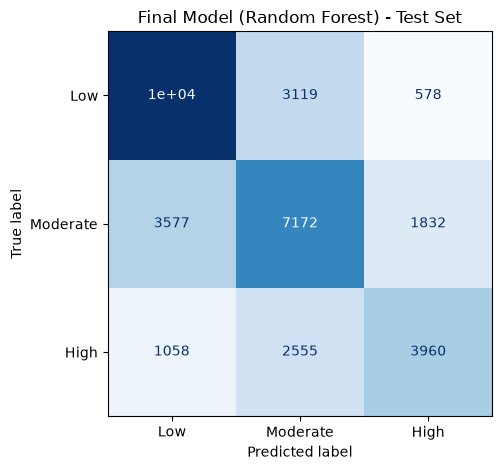

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Low", "Moderate", "High"],
                                        cmap="Blues", colorbar=False)
plt.title(f"Final Model ({best_name}) - Test Set")
plt.tight_layout()
plt.show()

## 7. Justification of the Final Model

**Final model: Random Forest** (`n_estimators=200`, `max_depth=25`, all 29 features)

**Reasons:**
1. **Highest Macro F1**, both before and after tuning (0.612 in cross-validation).
2. **Works well on unseen data.** Test Macro F1 = **0.615** and accuracy = **0.629**, almost the same as the
   cross-validation score (0.612). So the model is not overfitting to the training data.
3. **Finds High Risk routes reasonably well.** High Risk precision is 0.62 and recall is 0.52. When the model
   says "High Risk" it is right about 6 times out of 10. Low and High Risk are rarely confused.
4. **Gives a confidence value.** Random Forest outputs a probability for each class (`predict_proba`), so the
   system can show e.g. *"High Risk - 78% confidence"*, as planned in our proposal.
5. **Fast predictions.** KNN (second best) must compare every new record with all 137k training records,
   which is slow for a live system. Random Forest predicts quickly.

**Limitation:** Moderate Risk is the hardest class (F1 0.56), because it sits between Low and High. Scores are
limited by the available features: the dataset has no weather or air-traffic data.

## 8. Save the Final Model
The saved model and its feature list will be loaded by the backend in Stage 9.

In [12]:
os.makedirs("models", exist_ok=True)

# compress=3 makes the saved file smaller
joblib.dump(final_model, "models/final_model.joblib", compress=3)

# The backend must send the features in exactly this order
with open("models/final_features.json", "w") as f:
    json.dump(final_features, f)

print("Saved models/final_model.joblib and models/final_features.json")

Saved models/final_model.joblib and models/final_features.json
